# Pruebas de plots -- Entregable 2

Prototipado iterativo de las figuras de E2 (confirmado por el usuario
antes de avanzar), a diferencia de `pruebas_metricas_e2.ipynb` (que
prototipo los CALCULOS): este notebook parte directo de los archivos
ya generados en `data/processed/e2/` por `scripts_e2/p01_*.py` ...
`p09_*.py` -- no recalcula nada, solo lee y grafica. Cada seccion usa
el numero del dato/punto del calculo tal como se conversa con el
usuario.

No se sube a GitHub (`*.ipynb` esta en `.gitignore`, igual que
`pruebas_metricas_e2.ipynb`) -- prototipo de trabajo, se convertira a
`.py` en `scripts_e2/plots/` cuando el usuario confirme cada figura.

In [35]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

get_ipython().run_line_magic("matplotlib", "inline")

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "scripts_e2"))
import common_e2 as c2
MASKED = ROOT / "data/processed/masked"
INTERIM = ROOT / "data/interim/processed"
OUT_FIG = ROOT / "figures/e2"
OUT_FIG.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(ROOT / "scripts"))
import plot_common as pc

plt.rcParams.update({"font.size": 10})
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]

REF_INICIO, REF_FIN = 1981, 2014

## Dato 1: `indices_enso_*_ref1981-2014.csv` (p01_indices_enso.py)

Series mensuales ONI/RONI/ICEN de los 40 modelos + OBS (via
`c2.load_all_indices`, que junta el CSV de `p01` -- sin OBS por diseno
-- con el ONI/RONI/ICEN de ERSSTv5 calculado aparte). Empezamos con
ONI (Nino3.4), el indice mas estandar, como primer chequeo de sanidad
del pipeline.

In [2]:
df = c2.load_all_indices(REF_INICIO, REF_FIN)
registro = c2.read_model_registry()
numbers = [r["number"] for r in registro]
print(df.shape, df.index.min(), df.index.max())
df.filter(like="_ONI").head()

(1378, 123) 1900-02-01 00:00:00 2014-11-01 00:00:00


,M01_ONI,M02_ONI,M03_ONI,M04_ONI,M05_ONI,M06_ONI,M07_ONI,M08_ONI,M09_ONI,M10_ONI,...,M32_ONI,M33_ONI,M34_ONI,M35_ONI,M36_ONI,M37_ONI,M38_ONI,M39_ONI,M40_ONI,OBS_ONI
time,,,,,,,,,,,,,,,,,,,,,
1900-02-01,-0.4831,0.6406,-1.0423,-0.5149,-0.2051,1.3676,-1.1482,0.1450,0.2517,-1.8209,...,-1.9894,0.3660,-1.0750,-1.3845,-1.5562,0.3443,1.9714,-0.0179,0.5636,1.165297
1900-03-01,-0.3009,0.9622,-0.9532,-0.4399,-0.6717,0.6593,-0.8364,0.0992,0.2282,-1.8058,...,-1.6848,0.2875,-1.1555,-1.2738,-1.4637,0.1955,1.6105,0.1622,0.4417,0.995183
1900-04-01,-0.2514,0.9500,-0.7461,-0.5285,-0.9530,0.3642,-0.6658,0.0130,0.2363,-1.7155,...,-1.3969,0.3405,-1.1449,-1.4465,-1.4986,-0.0109,1.2477,0.2857,0.4048,0.877214
1900-05-01,-0.3160,0.8187,-0.4644,-0.5585,-0.9421,-0.1560,-0.5687,0.0301,0.3860,-1.4272,...,-1.1527,0.5360,-1.0593,-1.6446,-1.4876,-0.1098,0.9072,0.2738,0.2758,0.730512
1900-06-01,-0.4344,0.6800,-0.3035,-0.5182,-0.8521,-0.7384,-0.4297,0.0725,0.6577,-1.2611,...,-0.9679,0.6070,-0.9283,-1.6288,-1.3614,-0.3359,0.7818,0.3343,0.1560,0.626297


### 1a. Spaghetti plot -- ONI, 40 modelos + OBS

Estilo Kaur et al. (2021, Fig. 1a): cada modelo en linea fina y
semitransparente, OBS (ERSSTv5) encima en negro grueso. Lineas
punteadas en +-0.5 marcan el umbral oficial de inicio de evento
(Seccion 11 del marco teorico) -- si el pipeline esta bien, se deben
ver picos claros cruzando ese umbral en 1982-83, 1997-98, etc. en la
curva de OBS.

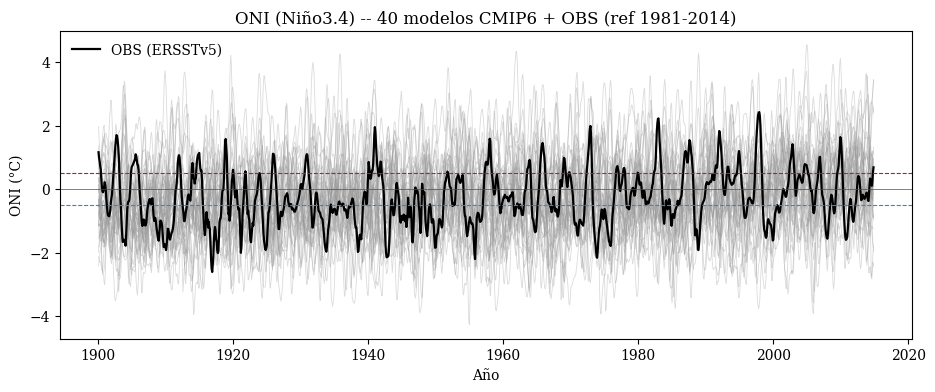

In [39]:
fig, ax = plt.subplots(figsize=(11, 4))

for number in numbers:
    ax.plot(df.index, df[f"{number}_ONI"], color="0.6", alpha=0.35, linewidth=0.6)

ax.plot(df.index, df["OBS_ONI"], color="black", linewidth=1.6, label="OBS (ERSSTv5)")
ax.axhline(0.5, color="firebrick", linestyle="--", linewidth=0.8)
ax.axhline(-0.5, color="steelblue", linestyle="--", linewidth=0.8)
ax.axhline(0, color="0.3", linewidth=0.5)

ax.set_ylabel("ONI (°C)")
ax.set_xlabel("Año")
ax.set_title(f"ONI (Niño3.4) -- 40 modelos CMIP6 + OBS (ref {REF_INICIO}-{REF_FIN})")
ax.legend(loc="upper left", frameon=False)
plt.savefig(OUT_FIG / "_test_serie.png", dpi=150, bbox_inches="tight")

### 1b. Barras de sigma(ONI) por modelo + OBS

Estilo Kaur et al. (2021, Fig. 1b): una barra por modelo, sigma de su
ONI en el periodo comun, OBS resaltado aparte -- visualiza de un
vistazo el rango de sigma_norm entre los 40 modelos (ya se sabe por
`taylor_nino34_ref1981-2014.csv` que va ~0.7-1.6+).

In [41]:
def plot_barras(ax,df,indice,cmod,cobs="firebrick"):
    s1 = pd.Series({n: df[f"{n}_{indice}"].std(ddof=1) for n in numbers})
    s1_obs = df["OBS_%s"%indice].std(ddof=1)
    ax.bar(s1.index, s1.values, color=cmod, width=0.95)
    ax.bar(["OBS"], [s1_obs], color=cobs, width=0.95)
    ax.set_ylabel("σ %s (°C)"%indice)
    # ax.set_title(f"std ONI (ref {REF_INICIO}-{REF_FIN})")
    ax.axhline(s1_obs, color="firebrick", ls="--", lw=.9,label=f"(ERSSTv5 σ={s1_obs:.2f})\nref {REF_INICIO}-{REF_FIN} ")
    ax.legend(loc="upper left", fontsize=8)
    return s1

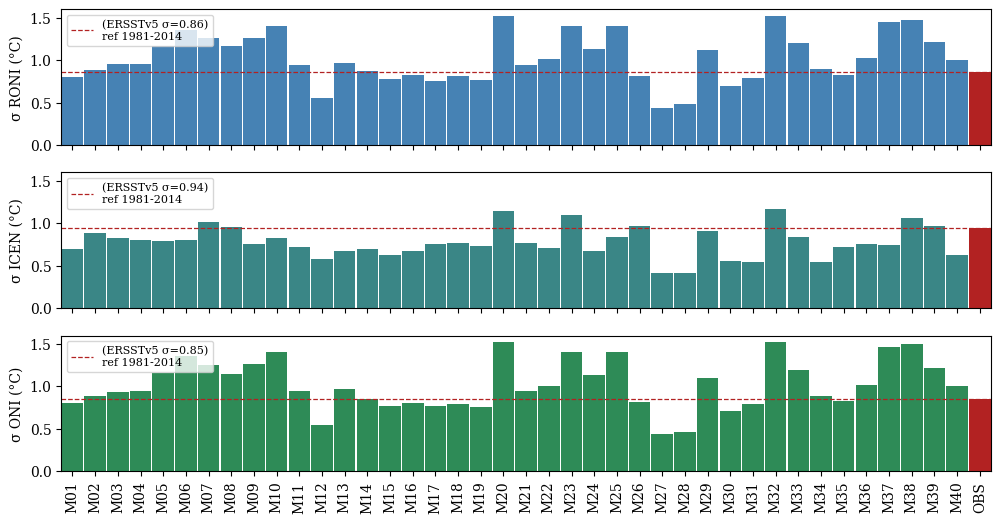

In [45]:
colores=["steelblue","#3a8686","seagreen"]
# --- Figura con 3 filas ---
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12,6), sharex=True, sharey=True)
ron=plot_barras(axes[0],df,"RONI",colores[0])
ice=plot_barras(axes[1],df,"ICEN",colores[1])
oni=plot_barras(axes[2],df,"ONI",colores[2])
# Rotar etiquetas del eje x solo en el panel inferior
axes[-1].tick_params(axis="x", rotation=90)
axes[-1].set_xlim(-0.5, len(s2) + 0.5)
plt.savefig(OUT_FIG / "_test_barras.png", dpi=150, bbox_inches="tight")

In [116]:
# oni: de DataFrame 1x40 → Serie con índice M01..M40
oni_s = oni.iloc[0]
oni_s.index = oni.columns

# Verifica que ron e ice tengan el mismo índice
ron_s = ron.reindex(oni_s.index)
ice_s = ice.reindex(oni_s.index)

# Ahora las restas funcionan elemento a elemento
ron_oni = ron_s - oni_s
oni_ice = oni_s - ice_s
ron_ice = ron_s - ice_s

# DataFrame (opcional, para inspeccionar)
ndf = pd.DataFrame({
    "RONI-ONI": ron_oni,
    "ICEN-ONI": oni_ice,
    "RONI-ICEN": ron_ice,
})

In [119]:
ndf1=ndf.sort_values('ICEN-ONI',ascending=False)

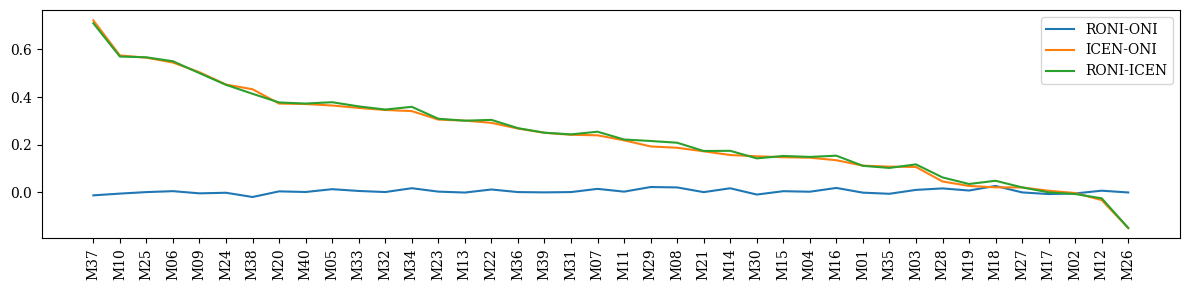

In [120]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(ndf1)
ax.tick_params(axis="x", rotation=90)
ax.legend(ndf.columns)
plt.tight_layout()
plt.show()

In [57]:
oni

,M01,M02,M03,M04,M05,M06,M07,M08,M09,M10,...,M31,M32,M33,M34,M35,M36,M37,M38,M39,M40
0,0.808868,0.889206,0.939049,0.948295,1.15757,1.354419,1.249425,1.149185,1.266167,1.406882,...,0.792287,1.516802,1.195949,0.880825,0.832009,1.020282,1.466921,1.492448,1.21556,1.001704


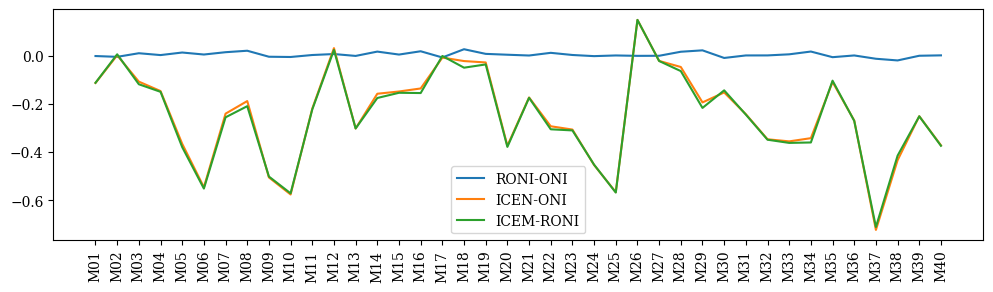

In [54]:
fig, axes = plt.subplots(1,1, figsize=(12,3),)
axes.plot(ron-oni,label='RONI-ONI')
axes.plot(ice-oni,label='ICEN-ONI')
axes.plot(ice-ron,label='ICEM-RONI')
axes.tick_params(axis="x", rotation=90)
axes.legend()

In [55]:
ron

M01    0.808095
M02    0.885092
M03    0.949915
M04    0.951504
M05    1.171404
M06    1.359948
M07    1.264564
M08    1.170410
M09    1.262495
M10    1.402153
M11    0.942983
M12    0.557249
M13    0.973277
M14    0.873889
M15    0.778225
M16    0.822803
M17    0.756472
M18    0.815417
M19    0.767378
M20    1.521597
M21    0.943880
M22    1.011652
M23    1.407269
M24    1.130287
M25    1.408338
M26    0.816380
M27    0.438776
M28    0.483393
M29    1.120337
M30    0.699859
M31    0.793983
M32    1.518626
M33    1.202300
M34    0.898700
M35    0.826515
M36    1.021946
M37    1.454860
M38    1.473435
M39    1.215980
M40    1.003748
dtype: float64